<a href="https://colab.research.google.com/github/elena-mamani/ReconocimientoDePatrones/blob/main/Challenge1_LandeoAndres_MamaniElena.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style='background:#8B0000; padding:20px; border-radius:8px; margin-bottom:10px'>
<h1 style='color:white; text-align:center; margin:0'>Reconocimiento de Patrones</h1>
<h2 style='color:#ffcccc; text-align:center; margin:5px 0 0 0'>Challenge 1 — Procesamiento y Visualización de Datos Biomédicos</h2>
<p style='color:#ffaaaa; text-align:center; margin:5px 0 0 0'>Ingeniería Biomédica · UPCH · 2026-1</p>
</div>

## Contexto clínico

Se te proporciona el dataset **Heart Failure Prediction** (Kaggle, fedesoriano, 2021), que contiene registros clínicos de **918 pacientes** con variables demográficas, de laboratorio y de electrocardiograma. La variable objetivo es `HeartDisease` (0 = sin enfermedad, 1 = con enfermedad).

Tu misión como analista: **explorar, limpiar, preprocesar y construir la matriz X e y** lista para ingresar a un modelo de ML clásico, aplicando todos los conceptos vistos en Clase 2.

---
> **Dataset:** `heart.csv`  
> **Fuente:** fedesoriano. (2021). *Heart Failure Prediction Dataset*. Kaggle. https://www.kaggle.com/fedesoriano/heart-failure-prediction

<div style='background:#e8f5e9; padding:8px 14px; border-left:4px solid #2e7d32; border-radius:4px; margin:8px 0'>
⏱️ <b>EN CLASE</b> — completa esto durante la sesión
</div>

---
## Ejercicio 1 — Diseño del pipeline (conceptual)

> **Antes de escribir una línea de código**, debes entender qué vas a hacer y por qué.

### 1.1 — Diagrama de bloques del pipeline

Completa el siguiente diagrama describiendo qué ocurre en cada etapa:

```
┌─────────────────┐     ┌─────────────────┐     ┌─────────────────┐
│                 │     │                 │     │                 │
│   heart.csv     │────▶│  [Adquisición] │────▶│  [EDA tabular]  │
│   (raw data)    │     │                 │     │                 │
│                 │     │  ¿Qué haces?:   │     │  ¿Qué haces?:   │
│  N=918, d=11    │     │  Se carga el    │     │   Visualización │
│                 │     │    dataset a    │     │  exploratoria de│
│                 │     │   dataframe     │     │    categoricas, │
│                 │     │                 │     │      números y  │
│                 │     │                 │     │      outliers   │
│                 │     │                 │     │                 │
└─────────────────┘     └─────────────────┘     └────────┬────────┘
                                                          │
                                                          ▼
┌─────────────────┐     ┌─────────────────┐     ┌─────────────────┐
│                 │     │                 │     │                 │
│  X ∈ ℝ^(N×d)    │◀───│Preprocesamiento │◀────│   [Limpieza]    │
│  y ∈ {0,1}^N    │     │                 │     │                 │
│                 │     │  ¿Qué haces?:   │     │  ¿Qué haces?:   │
│  listo p/ ML    │     │  Codificación   │     │  Corrección de  │
│                 │     │     y escalado  │     │   errores en la │
│                 │     │                 │     │   data tabular  │
└─────────────────┘     └─────────────────┘     └─────────────────┘
```

**📝 Tu respuesta (edita esta celda):**
- **1. Adquisición:** Se carga el dataset a dataframe
- **2. EDA tabular:** Visualización exploratoria de categoricas, números y outliers
- **3. Limpieza** Corrección de errores en la data tabular (outliers y/o NaNs)
- **4. Preprocesamiento:** Codificación y escalado

### 1.2 — Representación matemática del pipeline

Completa las dimensiones y operaciones matemáticas para este dataset:

**Punto de partida — el dataset crudo:**

$$\text{heart.csv} \rightarrow \text{DataFrame} \in \mathbb{R}^{N \times (d+1)}$$

donde $N = $ **918** pacientes y $d+1 = $ **12** columnas (features + target).

---

**Paso 1 — Separar features y target:**

$$\text{DataFrame} \xrightarrow{\text{split}} X_{\text{raw}} \in \mathbb{R}^{N \times \, \textbf{d}}, \quad y \in \{0,1\}^{\textbf{N}}$$

---

**Paso 2 — Codificación de variables categóricas (One-Hot):**

El dataset tiene columnas categóricas: `Sex`, `ChestPainType`, `RestingECG`, `ExerciseAngina`, `ST_Slope`.

¿Cuántas columnas nuevas generan? Completa:
(hint: drop_first)
| Variable | Categorías | Columnas One-Hot |
|---|---|---|
| Sex | M, F | **2** |
| ChestPainType | ATA, NAP, ASY, TA | **4** |
| RestingECG | Normal, ST, LVH | **3** |
| ExerciseAngina | Y, N | **2** |
| ST_Slope | Up, Flat, Down | **3** |
| **Total nuevas columnas** | | **14** |

$$X_{\text{raw}} \in \mathbb{R}^{N \times d_{\text{raw}}} \xrightarrow{\text{One-Hot}} X_{\text{enc}} \in \mathbb{R}^{N \times 9}$$

Con drop-first, se le resta una unidad al número de columnas de cada variable categórica y luego se suma la cantidad de columnas

---

**Paso 3 — Escalado Z-score:**

$$x'_j = \frac{x_j - \mu_j}{\sigma_j} \quad \Rightarrow \quad X_{\text{enc}} \xrightarrow{\text{Z-score}} X \in \mathbb{R}^{N \times 9}$$

Es la misma cantidad de columnas

¿Sobre qué conjunto calculas $\mu_j$ y $\sigma_j$? Sobre la data para entrenar. ¿Por qué? Porque la data de testeo influiría en la construcción del modelo, sería ya darle las respuestas.

### 1.3 — Predicción sobre el desbalance

Antes de cargar los datos, responde:

1. ¿Esperarías que este dataset esté desbalanceado? ¿Por qué clínicamente?
2. Si el 60% de los pacientes tiene `HeartDisease=1`, ¿qué accuracy obtendría un clasificador que **siempre** predice 1?
3. ¿Sería útil ese clasificador? ¿Por qué?

**📝 Tu respuesta (edita esta celda):**
1. Sí, esperaría que esté desbalanceado porque no se puede decir que la mitad de las personas que presentan las condiciones mencionadas tienen enfermedades cardiacas. De hecho, en una población real, la mayoría son pacientes sanos. Además hay más variables a tomar en cuenta que las presentadas.
2. La accuracy sería 0.6
3. No sería muy útil porque no detecta los casos negativos y está dejando al 40% con una clasificación incorrecta.

In [1]:
# ── Conexión con Google Drive ──────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


---
## Ejercicio 2 — Carga y EDA

### Paso 2.0 — Setup

In [2]:
# Colores institucionales UPCH
UPCH_RED   = '#8B0000'
UPCH_BLUE  = '#1565C0'
UPCH_GRAY  = '#4A4A4A'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split

# Ruta del dataset — ajusta según tu carpeta en Drive
DATA_PATH = Path('/content/drive/MyDrive/Challenges/Challenge_1/heart.csv')

print('Librerías cargadas correctamente ✓')

Librerías cargadas correctamente ✓


### Paso 2.1 — Carga y primera inspección

In [3]:
df = pd.read_csv(DATA_PATH)

print(f'Shape del dataset: {df.shape}')
print(f'\nPrimeras filas:')
df.head()

Shape del dataset: (918, 12)

Primeras filas:


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# Tipos de datos y valores nulos
print('Tipos de datos:')
print(df.dtypes)
print(f'\nValores nulos por columna:')
print(df.isnull().sum())

Tipos de datos:
Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object

Valores nulos por columna:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


In [ ]:
# Estadísticas descriptivas
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


### Paso 2.2 — Distribución de clases (desbalance)

> Recuerda lo que predijiste en Ejercicio 1.3. ¿Acertaste?

Distribución de clases:
  Sin enfermedad (0): 410 pacientes (0.4%)
  Con enfermedad (1): 508 pacientes (0.6%)


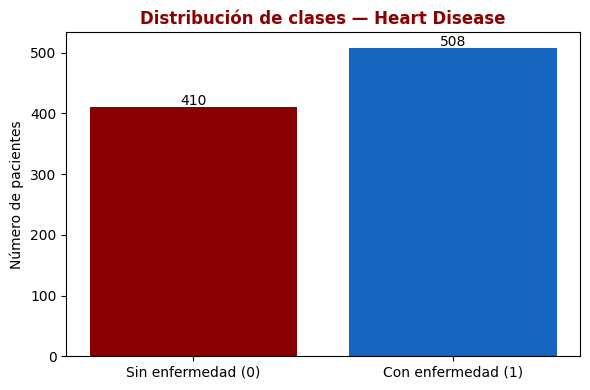


 → ¿Hay desbalance? ¿Qué implicaciones clínicas tiene?
Sí hay desbalance o sesgo en el dataset, la mayoría de pacientes tienen enfermedad y el restante no. 
 Las implicancias clínicas son que al querer predecir, se detectará mayor número de casos positivos. 
 Más sensibilidad pero menos especificidad


In [6]:
# @title
# --- COMPLETA EL CÓDIGO ---
# Visualiza la distribución de la variable objetivo HeartDisease
# Incluye: conteo por clase, porcentaje, y gráfico de barras con colores UPCH

conteo = df['HeartDisease'].value_counts()

# TODO 1: calcula el porcentaje de cada clase (usa conteo y len(df))
pct = conteo/len(df)

print('Distribución de clases:')
print(f'  Sin enfermedad (0): {conteo[0]} pacientes ({pct[0]:.1f}%)')
print(f'  Con enfermedad (1): {conteo[1]} pacientes ({pct[1]:.1f}%)')

fig, ax = plt.subplots(figsize=(6, 4))

# TODO 2: grafica las barras — usa ax.bar(), colores [UPCH_BLUE, UPCH_RED]
bars_n=ax.bar(conteo.index, conteo.values, color=[UPCH_BLUE, UPCH_RED])

ax.set_title('Distribución de clases — Heart Disease', fontweight='bold', color=UPCH_RED)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Sin enfermedad (0)', 'Con enfermedad (1)'])
ax.set_ylabel('Número de pacientes')

# TODO 3: agrega el valor numérico encima de cada barra con ax.text()
for bar in bars_n:
    height=bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 3, f'{height}', ha='center')

plt.tight_layout()
plt.savefig('distribucion_clases.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n → ¿Hay desbalance? ¿Qué implicaciones clínicas tiene?')

######
print('Sí hay desbalance o sesgo en el dataset, la mayoría de pacientes tienen enfermedad y el restante no. \n Las implicancias clínicas son que al querer predecir, se detectará mayor número de casos positivos. \n Más sensibilidad pero menos especificidad')
######

### Paso 2.3 — Visualización exploratoria de features numéricas

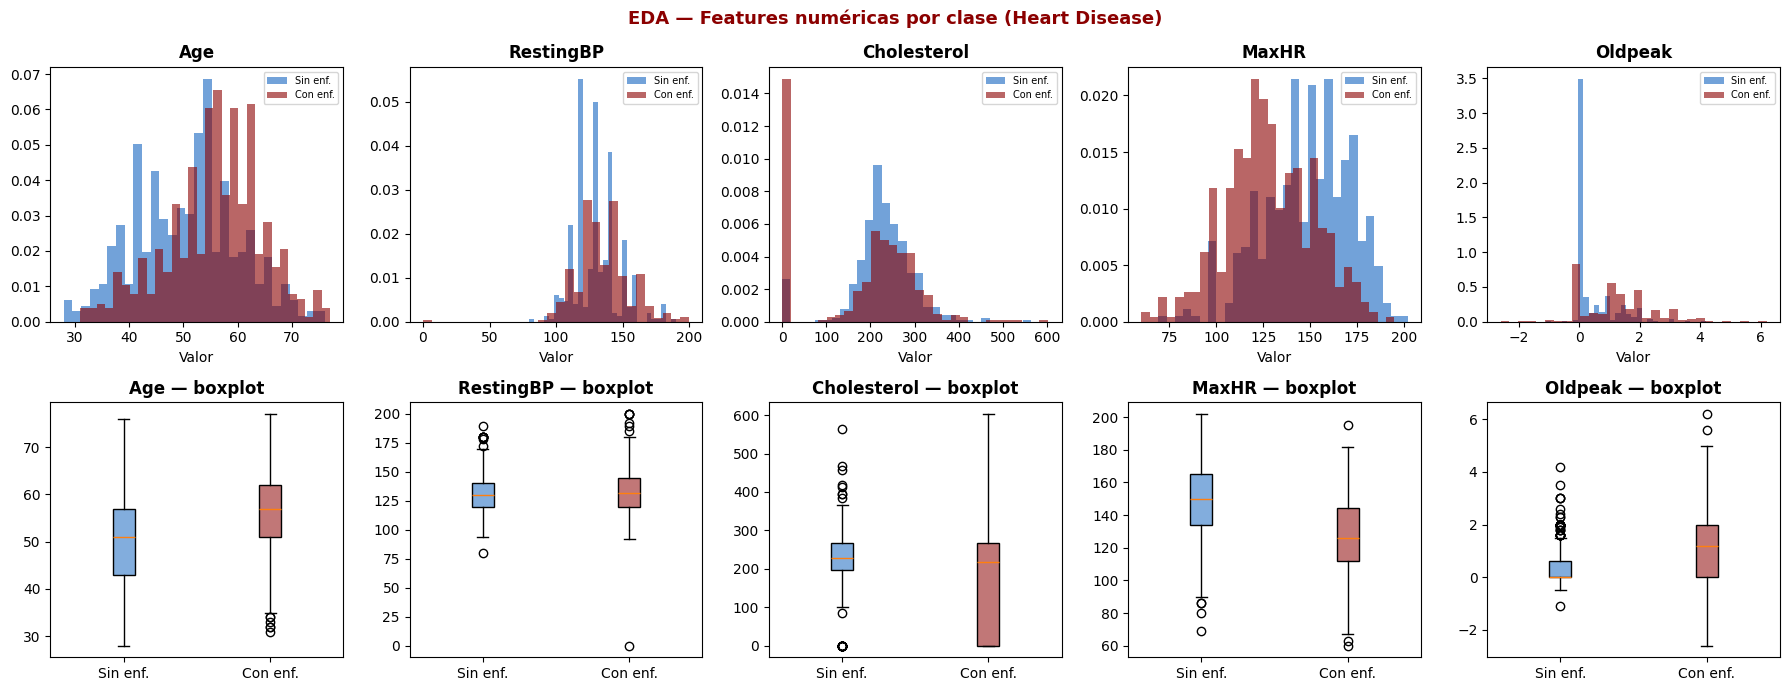


 → ¿Qué features parecen tener mayor poder discriminativo entre clases?
La feature con mayor poder observada en los gráficos de caja es OldPeak, 
 las medias son distintas a simple vista al igual que existe poco solapamiento entre data y bigotes de distintas clases 
 En menor medida también tienen poder factores como edad y MaxHR aunque existe solapamiento


In [7]:
# Features numéricas del dataset
features_num = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

fig, axes = plt.subplots(2, 5, figsize=(18, 7))

for i, feat in enumerate(features_num):
    # Fila 0: ya está resuelta — histograma por clase
    for clase, color, label in [(0, UPCH_BLUE, 'Sin enf.'), (1, UPCH_RED, 'Con enf.')]:
        axes[0, i].hist(
            df[df['HeartDisease'] == clase][feat],
            bins=30, alpha=0.6, color=color, label=label, density=True
        )
    axes[0, i].set_title(feat, fontweight='bold')
    axes[0, i].legend(fontsize=7)
    axes[0, i].set_xlabel('Valor')

    # --- COMPLETA EL CÓDIGO ---
    # TODO: Fila 1 — boxplot separado por clase en axes[1, i]
    # Pasos:
    #   1. Crea una lista con los valores de cada clase: [valores_clase0, valores_clase1]
    class_values=[df[df['HeartDisease']==0][feat], df[df['HeartDisease']==1][feat]]
    #   2. Llama a axes[1, i].boxplot() con patch_artist=True y labels=['Sin enf.', 'Con enf.']
    bp=axes[1, i].boxplot(class_values, patch_artist=True, tick_labels=['Sin enf.', 'Con enf.'])

    #   3. Colorea bp['boxes'][0] con UPCH_BLUE+'88' y bp['boxes'][1] con UPCH_RED+'88'
    bp['boxes'][0].set_facecolor(UPCH_BLUE +'88')
    bp['boxes'][1].set_facecolor(UPCH_RED +'88')

    #   4. Pon título: f'{feat} — boxplot'
    axes[1, i].set_title(f'{feat} — boxplot', fontweight='bold')

fig.suptitle('EDA — Features numéricas por clase (Heart Disease)',
             fontsize=13, fontweight='bold', color=UPCH_RED)
plt.tight_layout()
plt.savefig('eda_numericas.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n → ¿Qué features parecen tener mayor poder discriminativo entre clases?')

######
print('La feature con mayor poder observada en los gráficos de caja es OldPeak, \n las medias son distintas a simple vista al igual que existe poco solapamiento entre data y bigotes de distintas clases \n En menor medida también tienen poder factores como edad y MaxHR aunque existe solapamiento')
######


### Paso 2.4 — Visualización de features categóricas

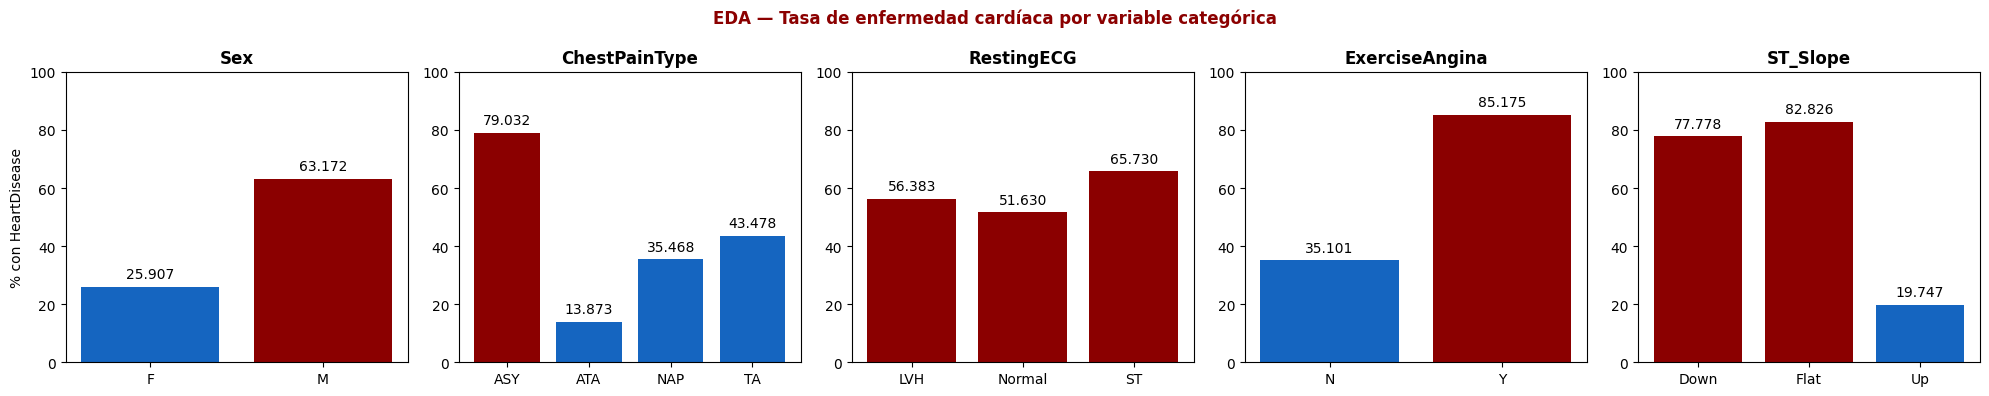


 → ¿Qué categorías tienen mayor riesgo de enfermedad cardíaca?
La categoría con mayor riesgo de enfermedad cardíaca es RestingECG, dentro ella la que tiene mayor tasa es ST. 
 También está la categoría ST_Slope con 77.778 para Down y 82.826 para Flat 
 Como último ejemplo tenemos a la categoría ExerciseAngina con el valor Y de 85.175


In [11]:
features_cat = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i, feat in enumerate(features_cat):
    # --- COMPLETA EL CÓDIGO ---
    # TODO 1: calcula la tasa de enfermedad por categoría
    #         (% de pacientes con HeartDisease=1 para cada valor de feat)
    #         pista: df.groupby(feat)
    tasa = df.groupby(feat)['HeartDisease'].mean()

    # TODO 2: asigna color UPCH_RED si tasa > 50%, UPCH_BLUE si no
    colores = [UPCH_RED if t > 0.5 else UPCH_BLUE for t in tasa.values]

    # TODO 3: grafica las barras y la línea de referencia al 50%
    bars_c=axes[i].bar(tasa.index, tasa.values*100, color=colores)

    axes[i].set_title(feat, fontweight='bold')
    axes[i].set_ylabel('% con HeartDisease' if i == 0 else '')
    axes[i].set_ylim(0, 100)

    # TODO 4: agrega el valor (ej: "72%") encima de cada barra con axes[i].text()
    for bar in bars_c:
      height=bar.get_height()
      axes[i].text(bar.get_x() + bar.get_width()/2, height + 3, f'{height:.3f}', ha='center')

fig.suptitle('EDA — Tasa de enfermedad cardíaca por variable categórica',
             fontsize=12, fontweight='bold', color=UPCH_RED)
plt.tight_layout()
plt.savefig('eda_categoricas.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n → ¿Qué categorías tienen mayor riesgo de enfermedad cardíaca?')

######
print('La categoría con mayor riesgo de enfermedad cardíaca es RestingECG, dentro ella la que tiene mayor tasa es ST. \n También está la categoría ST_Slope con 77.778 para Down y 82.826 para Flat \n Como último ejemplo tenemos a la categoría ExerciseAngina con el valor Y de 85.175')
######


---
## Ejercicio 3 — Limpieza de datos

### Paso 3.1 — Detección y manejo de outliers

> **⚠️ Recuerda:** en biomédica, un outlier puede ser un caso clínico real. Analiza antes de eliminar.

In [12]:
from scipy import stats

# --- COMPLETA EL CÓDIGO ---
# TODO: para cada feature numérica, calcula el z-score y cuenta cuántos
#       valores tienen |z| > 3. Imprime el resultado por feature.
# Pista: stats.zscore(), np.abs(), suma de booleanos

print('Detección de outliers (|z-score| > 3):')
print('-' * 45)
for feat in features_num:
    z_scores = stats.zscore(df[feat])
    booleans = np.abs(z_scores) > 3
    print('Outliers en', f'{feat}',':',sum(booleans))

Detección de outliers (|z-score| > 3):
---------------------------------------------
Outliers en Age : 0
Outliers en RestingBP : 8
Outliers en Cholesterol : 3
Outliers en MaxHR : 1
Outliers en Oldpeak : 7


In [13]:
# El dataset tiene Cholesterol = 0 en varios pacientes (imposible fisiológicamente)
# Esto es un error de adquisición, no un caso clínico real

print(f'Pacientes con Cholesterol = 0: {(df["Cholesterol"] == 0).sum()}')
print(f'Pacientes con RestingBP  = 0: {(df["RestingBP"]  == 0).sum()}')

df_clean = df.copy()

# --- COMPLETA EL CÓDIGO ---
# TODO: reemplaza los valores Cholesterol == 0 por NaN
# Pista: usa df_clean.loc[]
df_clean.loc[df_clean['Cholesterol'] == 0, 'Cholesterol'] = np.nan #np.nan reemplaza los valores con NaN

print(f'\nValores NaN en Cholesterol tras limpieza: {df_clean["Cholesterol"].isnull().sum()}')
print('→ La imputación se realizará en el Paso 4 (después del split, sobre train)')


Pacientes con Cholesterol = 0: 172
Pacientes con RestingBP  = 0: 1

Valores NaN en Cholesterol tras limpieza: 172
→ La imputación se realizará en el Paso 4 (después del split, sobre train)


---
## Ejercicio 4 — Preprocesamiento

### Paso 4.1 — Train/test split

> **Regla fundamental:** separar primero, preprocesar después. Nunca al revés — eso es **data leakage**.

In [15]:
TARGET = 'HeartDisease'
FEATURES_NUM = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak', 'FastingBS']
FEATURES_CAT = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

X_raw = df_clean[FEATURES_NUM + FEATURES_CAT].copy()
y     = df_clean[TARGET].values

# --- COMPLETA EL CÓDIGO ---
# TODO: split 80/20, estratificado por y, random_state=42
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X_raw, y, test_size=0.2, random_state=42, stratify=y)

print(f'Train: {X_train_raw.shape[0]} muestras')
print(f'Test:  {X_test_raw.shape[0]} muestras')
print(f'\nProporción HeartDisease=1 en train: {y_train.mean():.3f}')
print(f'Proporción HeartDisease=1 en test:  {y_test.mean():.3f}')
print('→ Con stratify, ambas proporciones deben ser similares ✓')


Train: 734 muestras
Test:  184 muestras

Proporción HeartDisease=1 en train: 0.553
Proporción HeartDisease=1 en test:  0.554
→ Con stratify, ambas proporciones deben ser similares ✓


### Paso 4.2 — Imputación de valores faltantes (sobre train)

In [17]:
# --- COMPLETA EL CÓDIGO ---
# TODO 1: calcula la mediana de Cholesterol SOLO sobre el train set
mediana_colesterol_train = X_train_raw['Cholesterol'].median()

X_train_imp = X_train_raw.copy()
X_test_imp  = X_test_raw.copy()

# TODO 2: imputa NaN en train y test usando la mediana del train
X_train_imp['Cholesterol'] = X_train_imp['Cholesterol'].fillna(mediana_colesterol_train)
X_test_imp['Cholesterol']  = X_test_imp['Cholesterol'].fillna(mediana_colesterol_train)

print(f'Mediana Cholesterol (train): {mediana_colesterol_train:.1f} mg/dL')
print(f'NaN restantes en train: {X_train_imp.isnull().sum().sum()}')
print(f'NaN restantes en test:  {X_test_imp.isnull().sum().sum()}')


Mediana Cholesterol (train): 238.0 mg/dL
NaN restantes en train: 0
NaN restantes en test:  0


### Paso 4.3 — Codificación de variables categóricas (One-Hot)

> Recuerda tu tabla del Ejercicio 1.2 — ¿coincide el número de columnas?

In [18]:
# One-Hot Encoding de variables categóricas
# drop_first=True para evitar multicolinealidad (dummy variable trap)

# --- COMPLETA EL CÓDIGO ---
# TODO: aplica pd.get_dummies a train y test usando FEATURES_CAT
X_train_enc = pd.get_dummies(X_train_imp, columns=FEATURES_CAT, drop_first=True)
X_test_enc  = pd.get_dummies(X_test_imp, columns=FEATURES_CAT, drop_first=True)

# Alinear columnas (por si alguna categoría no aparece en test)
X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

print(f'Shape antes de One-Hot: {X_train_raw.shape}')
print(f'Shape después de One-Hot: {X_train_enc.shape}')
print(f'\nColumnas generadas:')
print(list(X_train_enc.columns))
print("El número de columnas no coincidió, en la tabla se planteaban 14 pero en el código salieron 15")


Shape antes de One-Hot: (734, 11)
Shape después de One-Hot: (734, 15)

Columnas generadas:
['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak', 'FastingBS', 'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up']


### Paso 4.4 — Escalado Z-score

$$x'_j = \frac{x_j - \mu_j}{\sigma_j}$$

> **Anti-leakage:** `fit` solo sobre train, `transform` sobre train y test.

In [20]:
scaler = StandardScaler()

# --- COMPLETA EL CÓDIGO ---
# TODO: fit SOLO sobre train, transform sobre train y test
X_train = scaler.fit_transform(X_train_enc)
X_test  = scaler.transform(X_test_enc)

print(f'X_train: {X_train.shape}  dtype: {X_train.dtype}')
print(f'X_test:  {X_test.shape}')
print(f'\nMedia de X_train (debe ser ≈ 0): {X_train.mean():.4f}')
print(f'Std  de X_train (debe ser ≈ 1): {X_train.std():.4f}')
print(f'\nMedia de X_test (no será exactamente 0): {X_test.mean():.4f}')


X_train: (734, 15)  dtype: float64
X_test:  (184, 15)

Media de X_train (debe ser ≈ 0): -0.0000
Std  de X_train (debe ser ≈ 1): 1.0000

Media de X_test (no será exactamente 0): -0.0197


---
## Ejercicio 5 — Verificación final y resumen del pipeline

### Paso 5.1 — El dataset final en formato ML

In [27]:
# --- COMPLETA EL CÓDIGO ---
# TODO: imprime un resumen del dataset final mostrando:
#   - shape de X_train, X_test
#   - shape de y_train, y_test
#   - número y % de positivos en train y test
#   - el pipeline aplicado en una línea

print('=' * 50)
print('  RESUMEN — Dataset listo para ML clásico')
print('=' * 50)
print(f'X_train: {X_train.shape}  dtype: {X_train.dtype}')
print(f'X_test: {X_test.shape} dtype: {X_test.dtype}')
print(f'\ny_train: {y_train.shape}  dtype: {y_train.dtype}')
print(f'y_test: {y_test.shape} dtype: {y_test.dtype}')
print(f'\nHeartDisease = 1 en train: {(y_train.mean()*100):.3f}%, se encontraron {np.count_nonzero(y_train == 1)} valores positivos')
print(f'HeartDisease = 1 en test: {(y_test.mean()*100):.3f}%, se encontraron {np.count_nonzero(y_test == 1)} valores positivos')
print('\nPipeline:')
print('heart.csv --> Adquisición --> EDA tabular --> Limpieza --> Preprocesamiento --> Train/Test')


  RESUMEN — Dataset listo para ML clásico
X_train: (734, 15)  dtype: float64
X_test: (184, 15) dtype: float64

y_train: (734,)  dtype: int64
y_test: (184,) dtype: int64

HeartDisease = 1 en train: 55.313%, se encontraron 406 valores positivos
HeartDisease = 1 en test: 55.435%, se encontraron 102 valores positivos

Pipeline:
heart.csv --> Adquisición --> EDA tabular --> Limpieza --> Preprocesamiento --> Train/Test


### Paso 5.2 — Visualización Before vs After del preprocesamiento

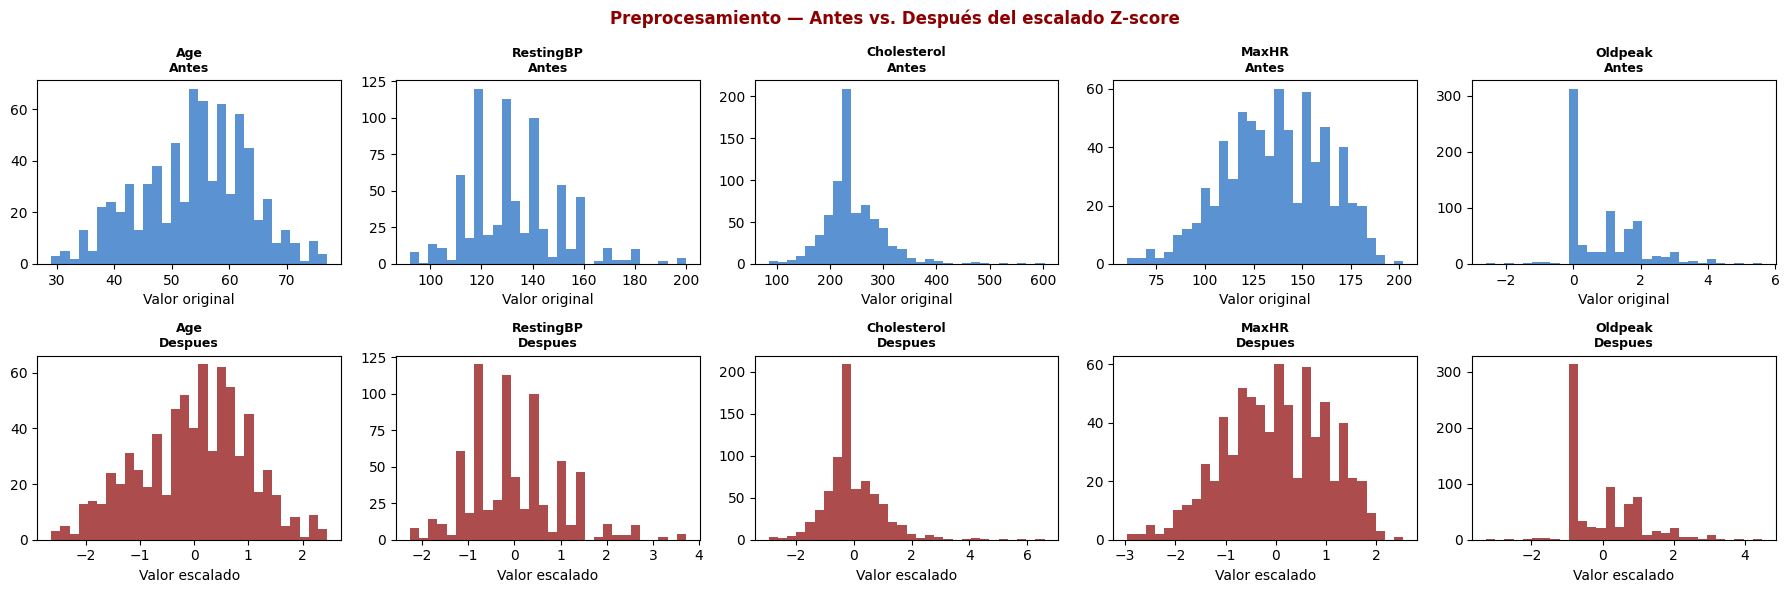

In [44]:
features_plot = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
idx_features  = [list(X_train_enc.columns).index(f) for f in features_plot]

fig, axes = plt.subplots(2, 5, figsize=(18, 6))

for i, (feat, idx) in enumerate(zip(features_plot, idx_features)):
    # Fila 0: antes del escalado — ya resuelta
    axes[0, i].hist(X_train_enc[feat].values, bins=30, color=UPCH_BLUE, alpha=0.7)
    axes[0, i].set_title(f'{feat}\nAntes', fontsize=9, fontweight='bold')
    axes[0, i].set_xlabel('Valor original')

    # --- COMPLETA EL CÓDIGO ---
    # TODO: Fila 1 — histograma de X_train[:, idx] después del escalado
    axes[1, i].hist(X_train[:,idx], bins=30, color=UPCH_RED, alpha=0.7)
    axes[1, i].set_title(f'{feat}\nDespues', fontsize=9, fontweight='bold')
    axes[1, i].set_xlabel('Valor escalado')

    ___


fig.suptitle('Preprocesamiento — Antes vs. Después del escalado Z-score',
             fontsize=12, fontweight='bold', color=UPCH_RED)
plt.tight_layout()
plt.savefig('before_after_scaling.png', dpi=150, bbox_inches='tight')
plt.show()


### Paso 5.3 — Mapa de correlaciones

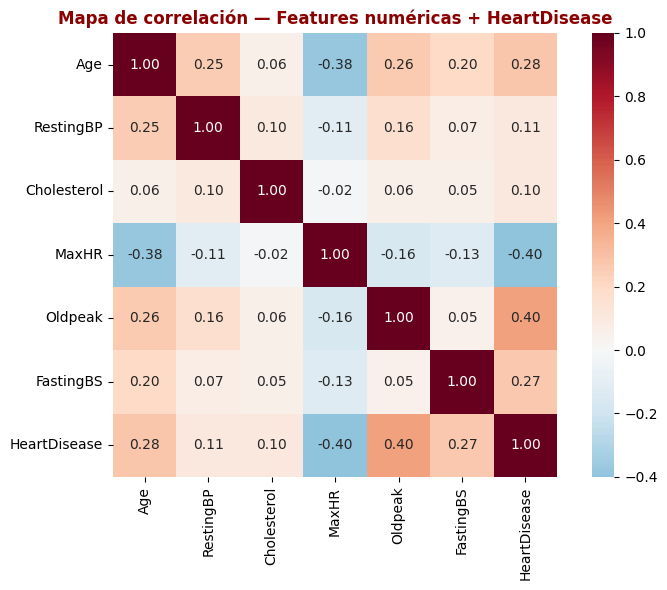

→ ¿Qué feature tiene mayor correlación (positiva o negativa) con HeartDisease?


In [48]:
cols_corr = FEATURES_NUM + [TARGET]
corr_matrix = df_clean[cols_corr].corr()

fig, ax = plt.subplots(figsize=(8, 6))

# --- COMPLETA EL CÓDIGO ---
# TODO: genera el heatmap con sns.heatmap
# Parámetros sugeridos: cmap='RdBu_r', annot=True, fmt='.2f', center=0, square=True
sns.heatmap(corr_matrix, cmap='RdBu_r', annot=True, fmt='.2f', center=0, square=True)

ax.set_title('Mapa de correlación — Features numéricas + HeartDisease',
             fontweight='bold', color=UPCH_RED)
plt.tight_layout()
plt.savefig('correlacion.png', dpi=150, bbox_inches='tight')
plt.show()
print('→ ¿Qué feature tiene mayor correlación (positiva o negativa) con HeartDisease?')
print('Las features que tienen mayor correlación con HeartDisease son MaxHR (-0.40) y Oldpeak (0.40)')


---
<div style='background:#f5f5f5; padding:15px; border-left:5px solid #8B0000; border-radius:4px'>
<b>Entrega:</b> Sube tu notebook ejecutado (.ipynb con outputs) a tu carpeta de GitHub del curso.<br>
<b>Nombre del archivo:</b> <code>Challenge1_ApellidoNombreDeAmbos.ipynb</code><br>
<b>Fecha límite:</b> antes de Clase 3
</div>